# Task 3 — Forest Cover Type Classification

**Objectif :** prédire le type de couverture forestière (7 classes) à partir de variables cartographiques et environnementales.

**Dataset :** Covertype (UCI) — chargé directement via `sklearn.datasets.fetch_covtype`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.figsize"] = (8, 5)

## 1. Chargement des données

**`SAMPLE_SIZE`** : le dataset complet fait 581 012 lignes. Pour aller vite en développement, on travaille sur un échantillon. Passe `SAMPLE_SIZE = None` pour utiliser tout le dataset une fois que le pipeline est validé.

In [2]:
SAMPLE_SIZE = 50_000  # None pour le dataset complet (581 012 lignes)

data = fetch_covtype(as_frame=True)
df = data.frame

if SAMPLE_SIZE is not None:
    df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print(df.shape)
df.head()

(50000, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,3351.0,206.0,27.0,726.0,124.0,3813.0,192.0,252.0,180.0,2271.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,2732.0,129.0,7.0,212.0,1.0,1082.0,231.0,236.0,137.0,912.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,2572.0,24.0,9.0,201.0,25.0,957.0,216.0,222.0,142.0,2191.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2824.0,69.0,13.0,417.0,39.0,3223.0,233.0,214.0,110.0,6478.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2529.0,84.0,5.0,120.0,9.0,1092.0,227.0,231.0,139.0,4983.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


## 2. Exploration et prétraitement



In [3]:
print("Valeurs manquantes :", df.isnull().sum().sum())
print()
print("Distribution des classes (Cover_Type) :")
print(df["Cover_Type"].value_counts().sort_index())

Valeurs manquantes : 0

Distribution des classes (Cover_Type) :
Cover_Type
1    18401
2    24299
3     3082
4      222
5      796
6     1463
7     1737
Name: count, dtype: int64


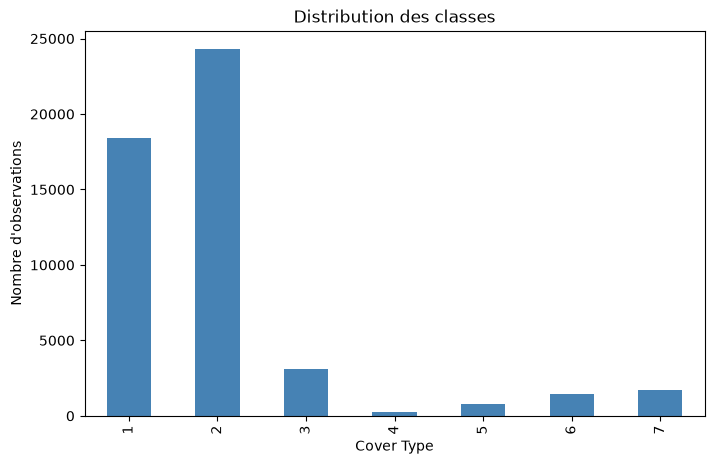

In [4]:
df["Cover_Type"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.xlabel("Cover Type")
plt.ylabel("Nombre d'observations")
plt.title("Distribution des classes")
plt.savefig("../outputs/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

→ Les classes ne sont pas parfaitement équilibrées (les types 1 et 2 dominent largement)

## 3. Split train/test

In [5]:
feature_cols = [c for c in df.columns if c != "Cover_Type"]
X = df[feature_cols]
y = df["Cover_Type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (40000, 54)  Test: (10000, 54)


## 4. Modèle 1 — Random Forest

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       0.88      0.87      0.88      3680
           2       0.88      0.92      0.90      4860
           3       0.81      0.90      0.85       617
           4       0.94      0.66      0.77        44
           5       0.93      0.43      0.59       159
           6       0.85      0.62      0.71       293
           7       0.93      0.82      0.87       347

    accuracy                           0.88     10000
   macro avg       0.89      0.74      0.80     10000
weighted avg       0.88      0.88      0.87     10000



## 5. Modèle 2 — XGBoost (bonus : comparaison de modèles)

In [7]:
# XGBoost attend des labels commençant à 0
xgb = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric="mlogloss")
xgb.fit(X_train, y_train - 1)
y_pred_xgb = xgb.predict(X_test) + 1

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           1       0.85      0.82      0.84      3680
           2       0.85      0.88      0.87      4860
           3       0.83      0.87      0.85       617
           4       0.88      0.66      0.75        44
           5       0.80      0.44      0.57       159
           6       0.76      0.69      0.72       293
           7       0.92      0.84      0.88       347

    accuracy                           0.85     10000
   macro avg       0.84      0.74      0.78     10000
weighted avg       0.85      0.85      0.84     10000



## 6. Comparaison Random Forest vs XGBoost

In [8]:
from sklearn.metrics import accuracy_score, f1_score

comparison = pd.DataFrame({
    "Modèle": ["Random Forest", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb)],
    "F1 (macro)": [f1_score(y_test, y_pred_rf, average="macro"), f1_score(y_test, y_pred_xgb, average="macro")],
})
comparison

,Modèle,Accuracy,F1 (macro)
0,Random Forest,0.8764,0.796419
1,XGBoost,0.8455,0.780957


## 7. Matrice de confusion (meilleur modèle)

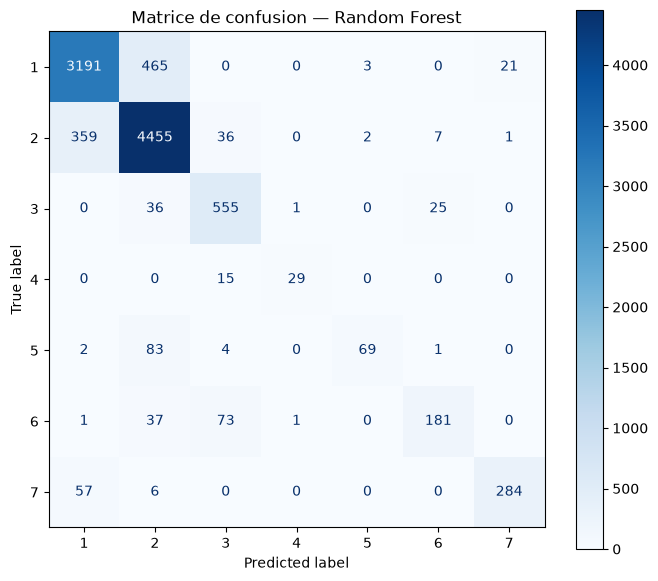

In [9]:
best_pred = y_pred_xgb if comparison.iloc[1]["Accuracy"] >= comparison.iloc[0]["Accuracy"] else y_pred_rf
best_name = "XGBoost" if comparison.iloc[1]["Accuracy"] >= comparison.iloc[0]["Accuracy"] else "Random Forest"

fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title(f"Matrice de confusion — {best_name}")
plt.savefig("../outputs/02_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Feature importance

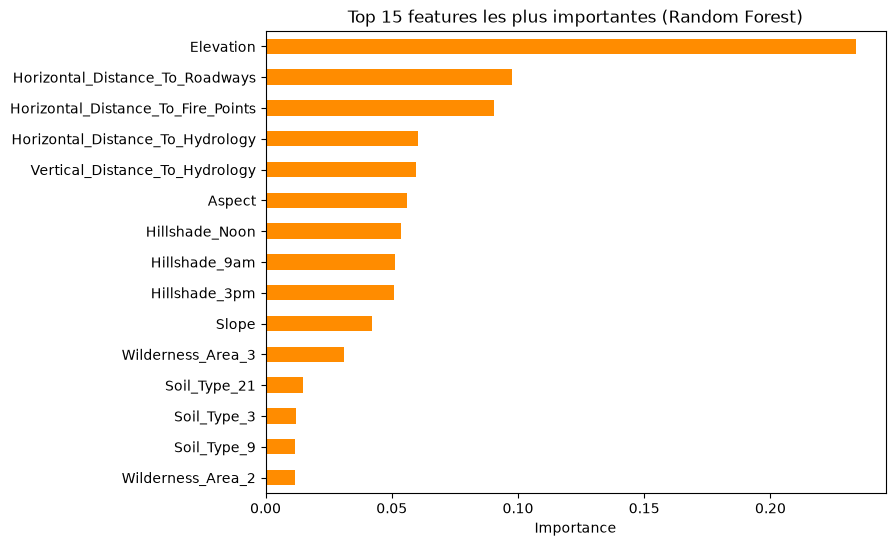

In [10]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="darkorange")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 features les plus importantes (Random Forest)")
plt.savefig("../outputs/03_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

→ `Elevation` (l'altitude) domine généralement très largement les autres features sur ce dataset — le type de forêt dépend fortement de l'altitude en zone montagneuse.

## 9. Bonus — Hyperparameter tuning

Un `GridSearchCV` complet sur ce dataset serait très long (beaucoup de lignes × beaucoup de combinaisons). On montre l'approche sur une grille réduite, à étendre une fois validée.

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score (F1 macro, CV) :", round(grid.best_score_, 4))

Meilleurs paramètres : {'max_depth': None, 'n_estimators': 100}
Meilleur score (F1 macro, CV) : 0.7595


**Prochaine étape possible :** élargir la grille (`max_features`, `min_samples_leaf`...) et repasser sur le dataset complet (`SAMPLE_SIZE = None`) une fois le pipeline validé.